In [5]:
# Colab usually has tensorflow preinstalled. This cell checks versions.
import sys
import tensorflow as tf
print("Python:", sys.version.splitlines()[0])
print("TensorFlow:", tf.__version__)

# If you want a specific TF version uncomment/install (only if needed)
# !pip install -q "tensorflow==2.13.0"


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, callbacks
from tensorflow.keras.datasets import mnist
import random
import os

# Reproducible-ish
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


In [7]:
# Load MNIST
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize to [0,1] and add channel dim
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# shape -> (N, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

print("train:", x_train.shape, "test:", x_test.shape)

# Optionally reduce dataset size for quick experiments
# x_train = x_train[:10000]
# x_test  = x_test[:2000]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
train: (60000, 28, 28, 1) test: (10000, 28, 28, 1)


In [8]:
# Hyperparameters
input_shape = (28,28,1)
latent_dim = 64   # size of latent vector (experiment with this)
batch_size = 128
epochs = 30

# Encoder
inputs = layers.Input(shape=input_shape)

x = layers.Conv2D(32, 3, activation='relu', padding='same', strides=2)(inputs)  # 14x14x32
x = layers.Conv2D(64, 3, activation='relu', padding='same', strides=2)(x)       # 7x7x64
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
latent = layers.Dense(latent_dim, name='latent_vector')(x)  # linear latent

encoder = models.Model(inputs, latent, name='encoder')
encoder.summary()

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7*7*64, activation='relu')(latent_inputs)
x = layers.Reshape((7,7,64))(x)
x = layers.Conv2DTranspose(64, 3, activation='relu', padding='same', strides=2)(x)  # 14x14x64
x = layers.Conv2DTranspose(32, 3, activation='relu', padding='same', strides=2)(x)  # 28x28x32
x = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)  # output in [0,1]

decoder = models.Model(latent_inputs, x, name='decoder')
decoder.summary()

# Autoencoder (encoder -> decoder)
ae_input = inputs
ae_latent = encoder(ae_input)
ae_output = decoder(ae_latent)
autoencoder = models.Model(ae_input, ae_output, name='autoencoder')
autoencoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,608 (1.64 MB)

 Trainable params: 428,608 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 64)             │       428,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       259,521 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,129 (2.63 MB)

 Trainable params: 688,129 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# For normalized [0,1] images, binary_crossentropy often works well; mse is fine too.
autoencoder.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses.BinaryCrossentropy(),  # or losses.MeanSquaredError()
    metrics=['mse']
)

# Print summary again (if needed)
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 64)             │       428,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       259,521 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,129 (2.63 MB)

 Trainable params: 688,129 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
checkpoint_path = "ae_checkpoint.h5"
cb_list = [
    callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss', verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]


In [11]:
history = autoencoder.fit(
    x_train, x_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=cb_list
)


Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2940 - mse: 0.0788
Epoch 1: val_loss improved from inf to 0.09550, saving model to ae_checkpoint.h5


469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.2938 - mse: 0.0787 - val_loss: 0.0955 - val_mse: 0.0112
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0910 - mse: 0.0096
Epoch 2: val_loss improved from 0.09550 to 0.08046, saving model to ae_checkpoint.h5


469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0910 - mse: 0.0096 - val_loss: 0.0805 - val_mse: 0.0064
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0800 - mse: 0.0061
Epoch 3: val_loss improved from 0.08046 to 0.07600, saving model to ae_checkpoint.h5


469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0800 - mse: 0.0061 - val_loss: 0.0760 - val_mse: 0.0050
Epoch 4/30
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0760 - mse: 0.0049
Epoch 4: val_loss improved from 0.07600 to 0.07369, saving model to ae_checkpoint.h5


469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0760 - mse: 0.0049 - val_loss: 0.0737 - val_mse: 0.0043
Epoch 5/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0739 - mse: 0.0043
Epoch 5: val_loss improved from 0.07369 to 0.07235, saving model to ae_checkpoint.h5


...

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0671 - mse: 0.0023 - val_loss: 0.0672 - val_mse: 0.0024
Epoch 25/30
462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0670 - mse: 0.0023
Epoch 25: val_loss improved from 0.06721 to 0.06714, saving model to ae_checkpoint.h5


469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0670 - mse: 0.0023 - val_loss: 0.0671 - val_mse: 0.0024
Epoch 26/30
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0670 - mse: 0.0023
Epoch 26: val_loss improved from 0.06714 to 0.06707, saving model to ae_checkpoint.h5


469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0670 - mse: 0.0023 - val_loss: 0.0671 - val_mse: 0.0024
Epoch 27/30
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0670 - mse: 0.0022
Epoch 27: val_loss improved from 0.06707 to 0.06703, saving model to ae_checkpoint.h5


469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0670 - mse: 0.0022 - val_loss: 0.0670 - val_mse: 0.0024
Epoch 28/30
462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0669 - mse: 0.0022
Epoch 28: val_loss did not improve from 0.06703
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0669 - mse: 0.0022 - val_loss: 0.0671 - val_mse: 0.0024
Epoch 29/30
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0668 - mse: 0.0022
Epoch 29: val_loss did not improve from 0.06703
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0668 - mse: 0.0022 - val_loss: 0.0671 - val_mse: 0.0024
Epoch 30/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0667 - mse: 0.0022
Epoch 30: val_loss improved from 0.06703 to 0.06695, saving model to ae_checkpoint.h5


469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0667 - mse: 0.0022 - val_loss: 0.0670 - val_mse: 0.0023
Restoring model weights from the end of the best epoch: 30.


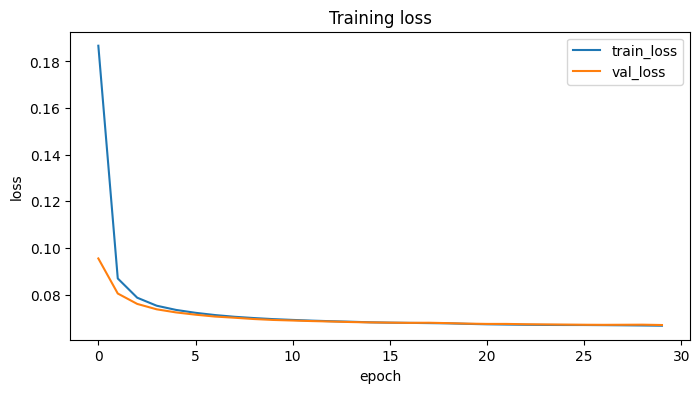

In [12]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend()
plt.title('Training loss')
plt.show()


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


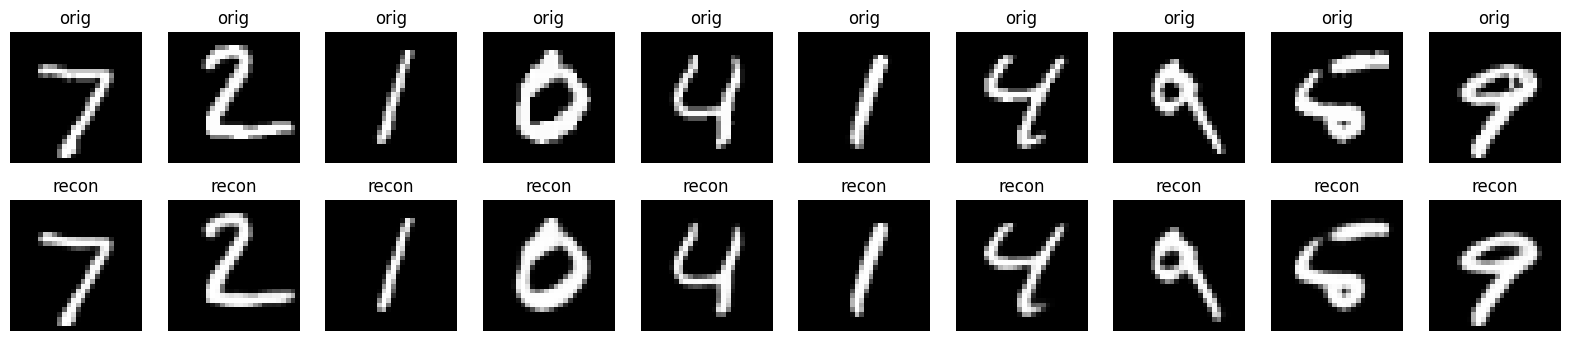

In [13]:
# Predict reconstructions
decoded = autoencoder.predict(x_test, batch_size=256)

# Display a grid of original & reconstructed images
n = 10
plt.figure(figsize=(20,4))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("orig")
    plt.axis('off')

    # reconstructed
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded[i].squeeze(), cmap='gray')
    plt.title("recon")
    plt.axis('off')
plt.show()


In [14]:
encoder.save("encoder_model")
decoder.save("decoder_model")
autoencoder.save("autoencoder_full_model")

# To load later:
# loaded_encoder = tf.keras.models.load_model("encoder_model")
# loaded_decoder = tf.keras.models.load_model("decoder_model")
# loaded_ae = tf.keras.models.load_model("autoencoder_full_model")


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=encoder_model.